# Imports

In [10]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy
import seaborn as sns

In [16]:
from pathlib import Path
from matplotlib import pyplot as plt

In [17]:
save_path = Path('~/data/drvi').expanduser()

# Parametrize some nonlinear positive functions

In [3]:
from scipy.interpolate import PchipInterpolator

def get_random_monotone_function(size=10):
    a = np.random.uniform(0.1, +.9, size)
    b = np.random.uniform(0.1, +.9, size)
    a, b = np.minimum(a, b), np.maximum(a, b)

    x_points = [-0.3, 0., 0.3, 0.7, 1., 1.3]
    y_points = [-a, a*0, a, b, b*0+1, (b*0+2)-b]

    f = PchipInterpolator(x_points, y_points)

    return f

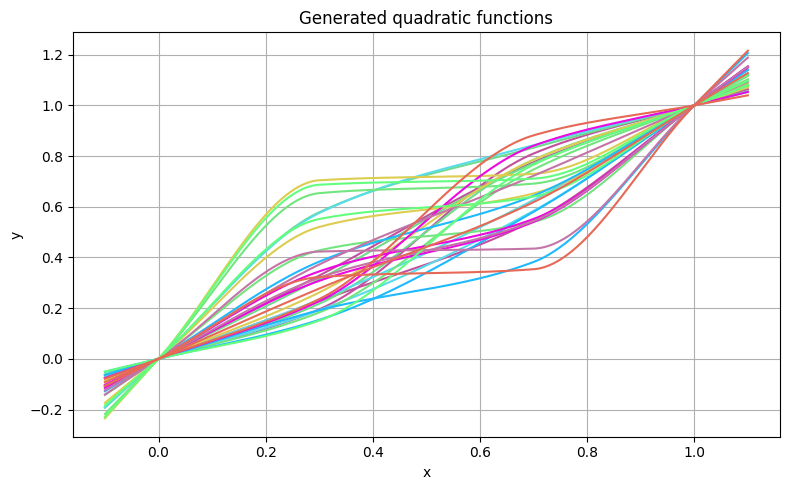

In [4]:
# Plot
plt.figure(figsize=(8, 5))

for i in range(10):
    f = get_random_monotone_function(3)
    x_vals = np.linspace(-0.1, 1.1, 500)
    y_vals = f(x_vals)
    
    plt.plot(x_vals, y_vals, color=np.random.rand(3,))
    plt.title('Generated quadratic functions')
    plt.xlabel('x')
    plt.ylabel('y')

plt.grid(True)
plt.tight_layout()
plt.show()

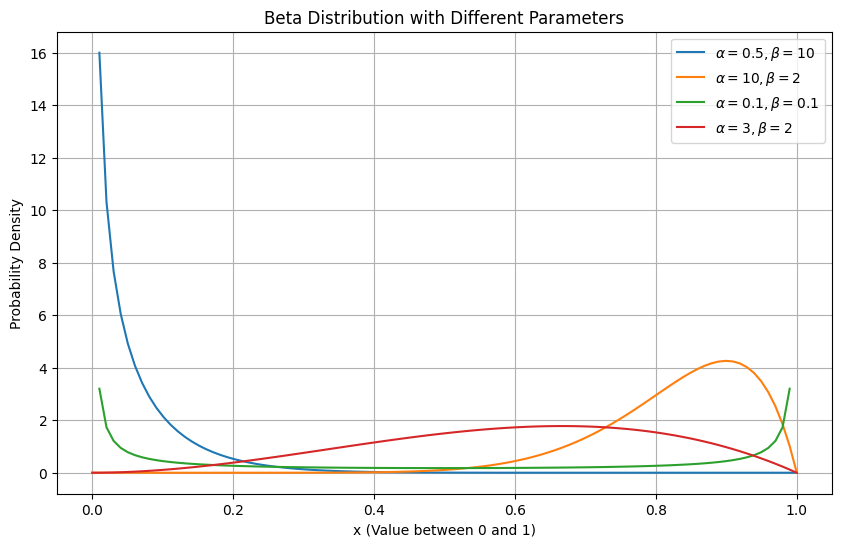

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define the alpha and beta parameters
alpha_values = [0.5,  10, 0.1, 3]
beta_values = [10, 2, 0.1, 2]
x = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(10, 6))

for a, b in zip(alpha_values, beta_values):
    # Calculate the probability density function (PDF) for the given alpha and beta
    pdf = beta.pdf(x, a, b)
    # Plot the PDF
    ax.plot(x, pdf, label=f'$\\alpha={a}, \\beta={b}$')

# Add labels and title
ax.set_xlabel('x (Value between 0 and 1)')
ax.set_ylabel('Probability Density')
ax.set_title('Beta Distribution with Different Parameters')

# Add a legend
ax.legend(loc='best')

# Add a grid for better readability
ax.grid(True)

# Show the plot
plt.show()

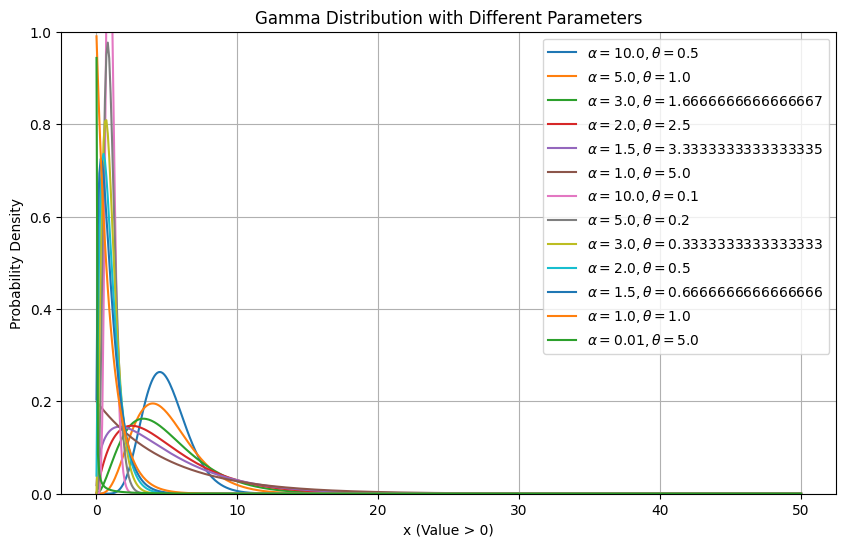

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Define the alpha (shape) and scale (theta) parameters for the Gamma distribution
alpha_values = np.asarray([10, 5, 3, 2, 1.5, 1, 10, 5, 3, 2, 1.5, 1, 0.01])
mean_values = np.asarray([5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 0.05])
scale_values = mean_values / alpha_values

x = np.linspace(0.01, 50, 500)

fig, ax = plt.subplots(figsize=(10, 6))

for a, s in zip(alpha_values, scale_values):
    # Calculate the probability density function (PDF) for the given alpha (shape) and scale
    pdf = gamma.pdf(x, a, scale=s)
    # Plot the PDF
    ax.plot(x, pdf, label=f'$\\alpha={a}, \\theta={s}$') # Using theta for scale parameter in label

# Add labels and title
ax.set_xlabel('x (Value > 0)')
ax.set_ylabel('Probability Density')
ax.set_title('Gamma Distribution with Different Parameters')
ax.set_ylim(0, 1)

# Add a legend
ax.legend(loc='best')

# Add a grid for better readability
ax.grid(True)

# Show the plot
plt.show()

In [7]:
def make_ground_truth(
    n_process = 30,
    n_pert = 100,
    n_cells_per_pert = 500,
    n_control_cells = 1000,
    max_process_per_pert = 5,
    n_genes = 1000,
):
    # generate ground_truth matrix
    ## One hot encoding
    ground_truth = np.zeros((n_pert, n_process))
    for pert in range(n_pert):
        n_involved_processes = np.random.choice(np.arange(1, max_process_per_pert + 1).astype(int))
        involved_process = np.random.choice(np.arange(n_process), n_involved_processes)
        ground_truth[pert, involved_process] = 1
    
    # Make sure processes are distinguishable
    assert len(set(["".join(x) for x in ground_truth.astype(str).T])) == n_process

    ## sort for easier downstream visualization
    ground_truth = ground_truth[np.lexsort(-ground_truth.T[::-1])]
    ## extend to number of cells
    ground_truth = np.broadcast_to(np.expand_dims(ground_truth, 1), (n_pert, n_cells_per_pert, n_process)).reshape(-1, n_process)
    ground_truth = np.pad(ground_truth, ((0, n_control_cells), (0, 0)), 'constant', constant_values=0)

    ## Make sure every ground-truth process in covered
    assert np.all(ground_truth.max(axis=0) == 1)

    # Generate latent space
    inactive_latent = np.zeros(ground_truth.shape)
    active_latent = np.random.beta(10.0, 2.0, ground_truth.shape)
    z = active_latent * ground_truth + inactive_latent * (1 - ground_truth)

    pert = np.concatenate([np.repeat(np.arange(n_pert) + 1, n_cells_per_pert), np.repeat(0, n_control_cells)])
    
    return ground_truth, z, pert

In [8]:
class MonotoneDecoder:
    def __init__(self, x_dim, x_n_nonzero=(5,10), gene_max=(1, 10)):
        self.x_dim = x_dim

        self.x_n_nonzero = np.random.randint(x_n_nonzero[0], x_n_nonzero[1]+1)

        self.activation_functions = get_random_monotone_function(size=self.x_n_nonzero)
        self.weights = np.random.uniform(*gene_max, size=self.x_n_nonzero)
        self.mapping = np.zeros((self.x_n_nonzero, x_dim))  # n_nonzero x x_dim
        self.mapping[np.arange(self.x_n_nonzero), np.random.choice(np.arange(x_dim), self.x_n_nonzero, replace=False)] = 1
    
    def __call__(self, z):
        z  # n_sample
        h = self.activation_functions(z).clip(min=0)  # n_sample x n_nonzero
        h = h * self.weights  # n_sample x n_nonzero
        x = h @ self.mapping  # n_nonzero x x_dim
        return x
        
class AdditiveDecoders:
    def __init__(self, z_dim, x_dim, x_n_nonzero=(5, 10), gene_max=(1, 10), gamma_shape=(1, 5), 
                 noise_gamma_scale=(1, 5), noise_gamma_shape=(0.01, 0.05), agg='LSE', **kwargs):

        self.z_dim = z_dim
        self.x_dim = x_dim
        self.x_n_nonzero = x_n_nonzero
        self.gene_max = gene_max
        self.gamma_shape = gamma_shape
        self.noise_gamma_scale = noise_gamma_scale
        self.noise_gamma_shape = noise_gamma_shape
        self.agg = agg
        
        self.decoders = [
            MonotoneDecoder(
                x_dim=self.x_dim,
                x_n_nonzero=self.x_n_nonzero,
                gene_max=gene_max,
                **kwargs
            ) for _ in range(self.z_dim)
        ]

        self.noise_dims = 1 - np.max([d.mapping.max(axis=0).flatten() for d in self.decoders], axis=0, keepdims=True)
            
    def split_latent(self, z):
        return np.array_split(z, self.z_dim, axis=-1)

    def _add_noise(self, x):
        x = x.copy()
        
        # Create noise from same distribution of non-noise genes
        non_noise_genes = np.argwhere(self.noise_dims.flatten() == 0).flatten()
        noise_genes = np.argwhere(self.noise_dims.flatten() == 1).flatten()
        
        non_noise_samples = x[:, non_noise_genes]
        
        # Randomly shuffle each gene independently
        shuffled_noise = np.empty((x.shape[0], len(noise_genes)))
        
        for i in range(len(noise_genes)):
            gene_values = non_noise_samples[:, i % non_noise_samples.shape[1]].flatten().copy()
            np.random.shuffle(gene_values)
            shuffled_noise[:, i] = gene_values
        
        # Add noise only to noise genes
        x[:, noise_genes] += shuffled_noise
        return x
    
    
    def __call__(self, z):
        z_components = self.split_latent(z)
        
        outputs = []
        for z_comp, decoder in zip(z_components, self.decoders):
            decoded_chunk = decoder(z_comp.flatten())
            outputs.append(decoded_chunk)
        outputs = np.stack(outputs, axis=-1)
            
        # if self.agg == 'LSE':
        #     result = scipy.special.logsumexp(outputs, axis=-1) -  np.log(self.z_dim)
        #     result = np.expm1(result)
        # else:
        #     raise NotImplementedError(f"The aggregation {self.agg} is not implemented.")

        # # Add noise!
        # result += 0.01 # * self.noise_dims

        # # add constant activity for noise dims
        # result += (np.random.uniform(size=self.x_dim) < 0.25) * np.random.uniform(*self.gene_max, size=self.x_dim) * self.noise_dims
        
        
        # # Add gamma noise
        # gamma_shape = np.random.uniform(1., 5, size=self.x_dim)
        # gamma_scale = result / gamma_shape
        
        # result = np.random.gamma(gamma_shape, gamma_scale)
                
        # # result = self._add_noise(result)

        # assert result.min() >= 0
        # result = result / np.median(result.sum(axis=1, keepdims=True))
        # result = np.random.poisson(lam=1e4 * result)

        #####################
        # result = np.expm1(outputs)
        result = outputs
        gamma_shape = np.random.uniform(*self.gamma_shape, size=(self.x_dim, 1)) / 5
        gamma_scale = result / gamma_shape
        
        result = np.random.gamma(gamma_shape, gamma_scale)
        result = np.sum(result, axis=-1)

        # Add noise
        result += np.random.gamma(
            np.ones_like(result) * np.random.uniform(*self.noise_gamma_shape, size=(self.x_dim)), 
            np.random.uniform(*self.noise_gamma_scale, size=(self.x_dim)),
        )

        print("Median library size: ", np.median(result.sum(axis=1, keepdims=True)))
        
        # result = result / np.median(result.sum(axis=1, keepdims=True))
        result = np.random.poisson(lam=result)
        
        return result

In [13]:
def generate_simulated_adata(
    seed=0,
    n_process=20,
    n_genes=1000,
    process_effect_size=(2, 100),
    gene_max=(1, 100),
    gamma_shape=(1, 5),
    noise_gamma_scale=(0.1, 10),
    noise_gamma_shape=(0.05, 0.1),
    n_pert=50,
    n_cells_per_pert=100,
    n_control_cells=1000,
    max_process_per_pert=4,
):
    np.random.seed(seed)

    ground_truth, z, pert = make_ground_truth(
        n_process=n_process,
        n_pert=n_pert,
        n_cells_per_pert=n_cells_per_pert,
        n_control_cells=n_control_cells,
        max_process_per_pert=max_process_per_pert,
        n_genes=n_genes,
    )

    decoder = AdditiveDecoders(
        z_dim=n_process,
        x_dim=n_genes,
        x_n_nonzero=process_effect_size,
        gene_max=gene_max,
        gamma_shape=gamma_shape,
        noise_gamma_scale=noise_gamma_scale,
        noise_gamma_shape=noise_gamma_shape,
    )
    observations = decoder(z)

    adata = ad.AnnData(observations)

    adata.obs["pert"] = pert
    adata.obs["pert"] = pd.Categorical(adata.obs["pert"])
    adata.obsm["ground_truth_identity"] = ground_truth
    adata.obsm["ground_truth_z"] = z
    adata.obs["perfect_order"] = np.arange(adata.n_obs)

    adata.varm["ground_truth_effect"] = np.stack(
        [d.mapping.sum(axis=0).flatten() for d in decoder.decoders], axis=1
    )
    # Sort genes by their ground truth effect for consistent ordering
    adata = adata[:, np.lexsort(-adata.varm["ground_truth_effect"].T[::-1])].copy()
    adata.var["perfect_order"] = np.arange(adata.n_vars)

    affected_genes = {
        str(i): np.argwhere(d.mapping.sum(axis=0)).flatten().astype(str).tolist()
        for i, d in enumerate(decoder.decoders)
    }
    adata.uns["affected_genes"] = affected_genes

    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    return adata

In [20]:
simulated_datasets = {
    'synthetic_data_unique_no_noise': generate_simulated_adata(max_process_per_pert=1, noise_gamma_scale=(0, 0)),
    'synthetic_data_unique': generate_simulated_adata(max_process_per_pert=1),
    'synthetic_data_overlapping_4_no_noise': generate_simulated_adata(max_process_per_pert=4, noise_gamma_scale=(0, 0)),
    'synthetic_data_overlapping_4': generate_simulated_adata(max_process_per_pert=4),
}

Median library size:  1529.1791832755603


/home/icb/amirali.moinfar/miniconda3/envs/drvi/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


Median library size:  1910.8672081600844
Median library size:  3891.7530505179047


/home/icb/amirali.moinfar/miniconda3/envs/drvi/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


Median library size:  4268.246337188936


synthetic_data_unique_no_noise


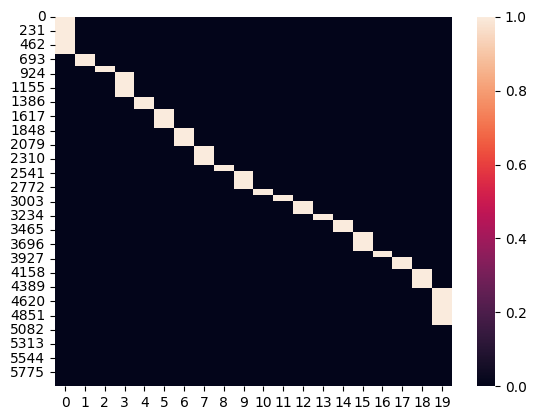

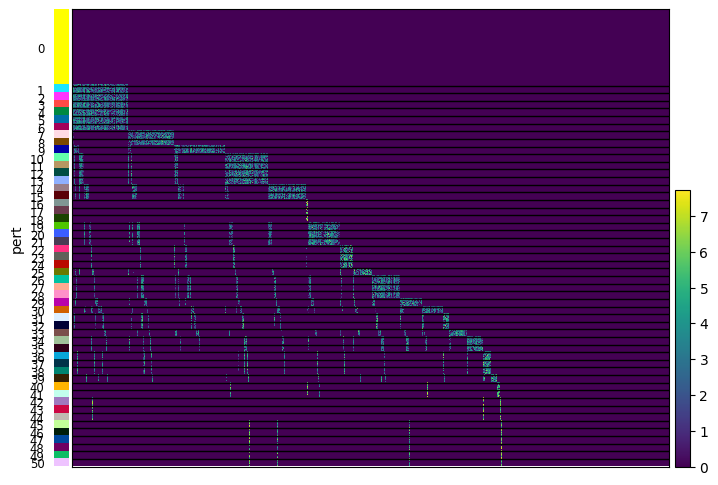

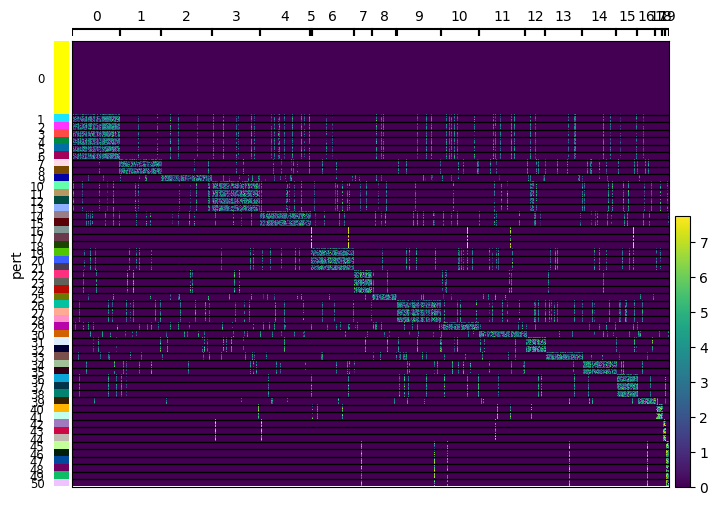

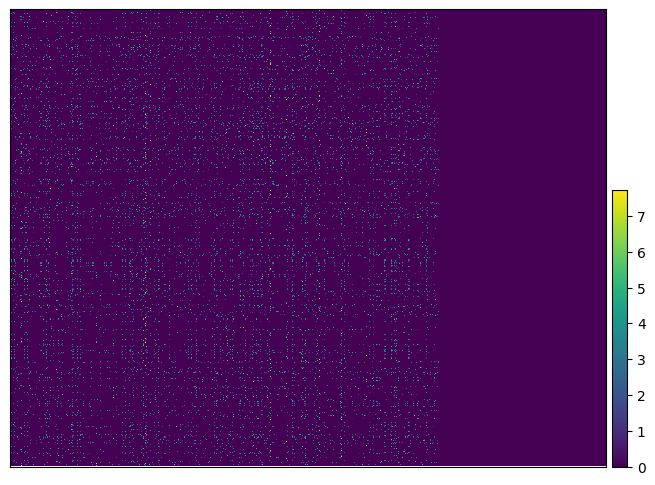

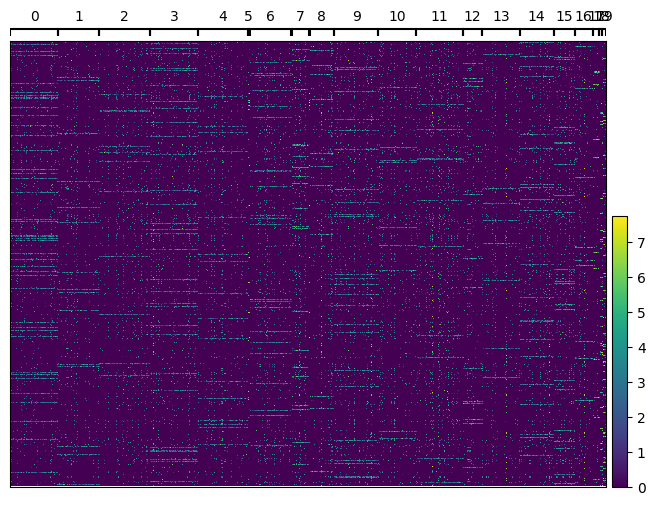

/home/icb/amirali.moinfar/miniconda3/envs/drvi/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


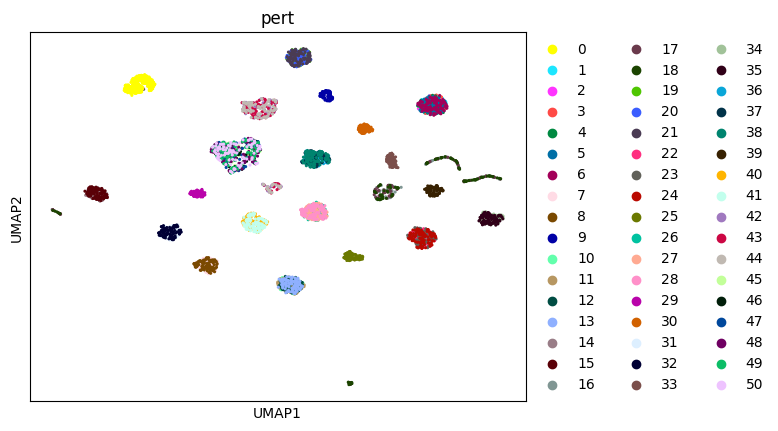

synthetic_data_unique


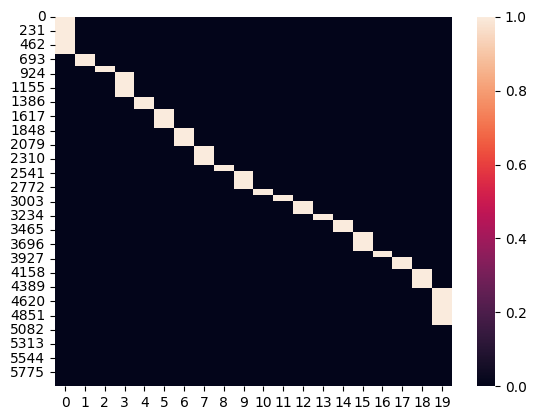

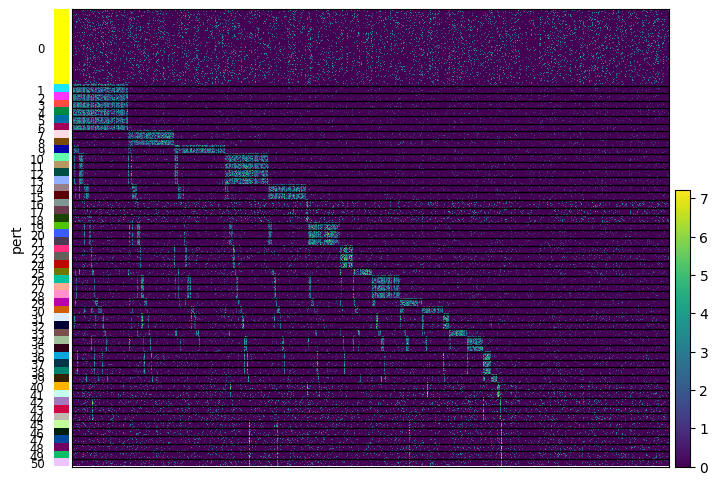

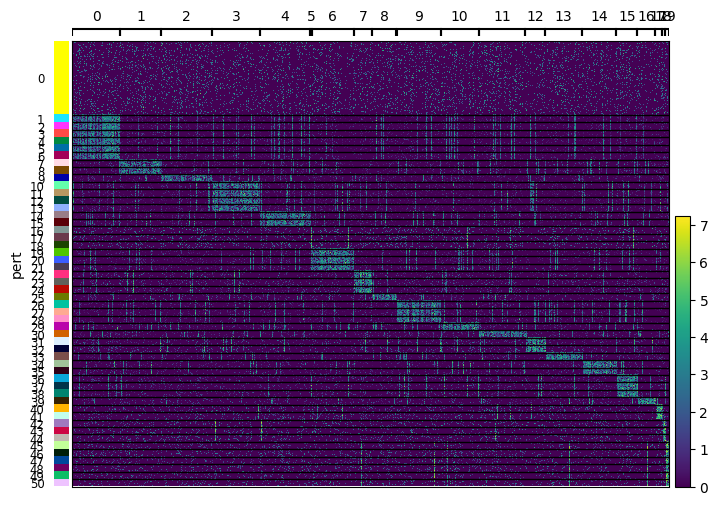

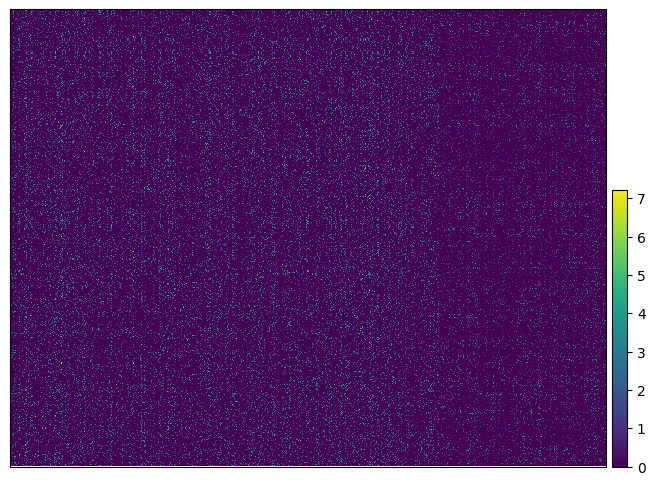

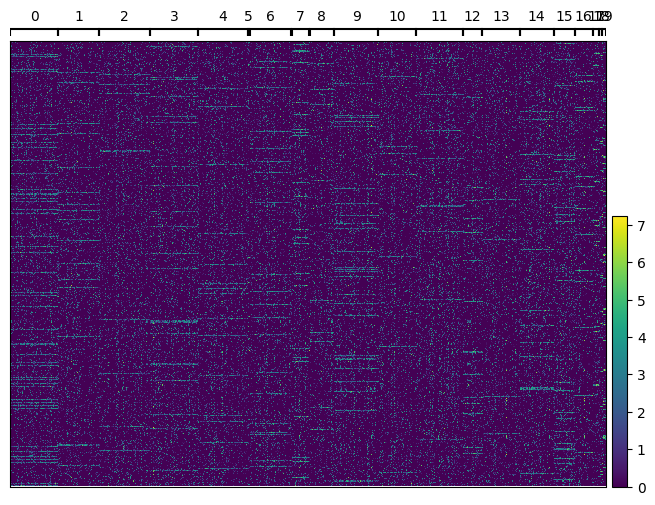

/home/icb/amirali.moinfar/miniconda3/envs/drvi/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


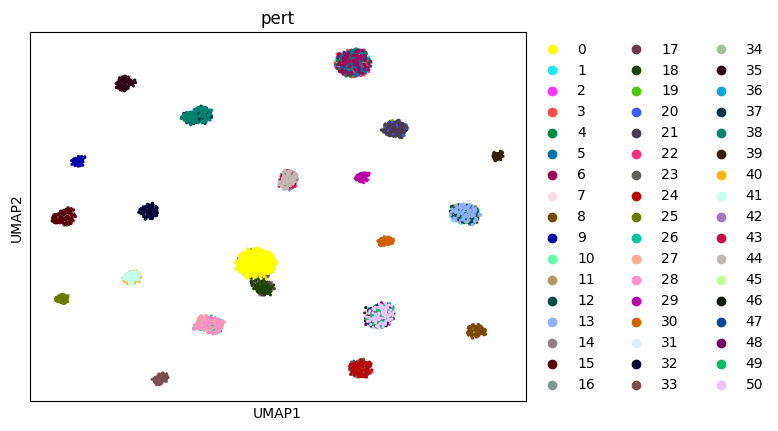

synthetic_data_overlapping_4_no_noise


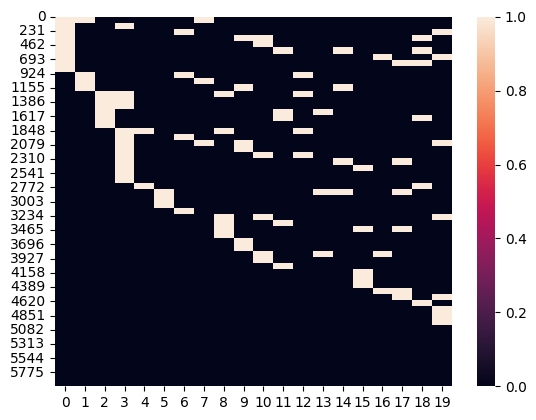

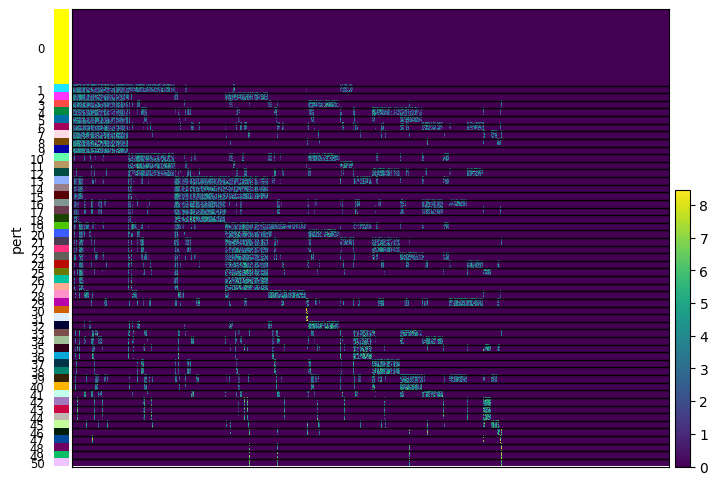

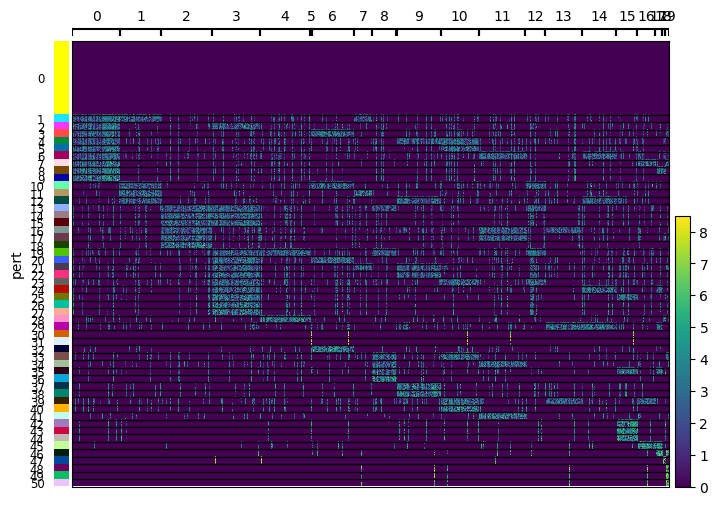

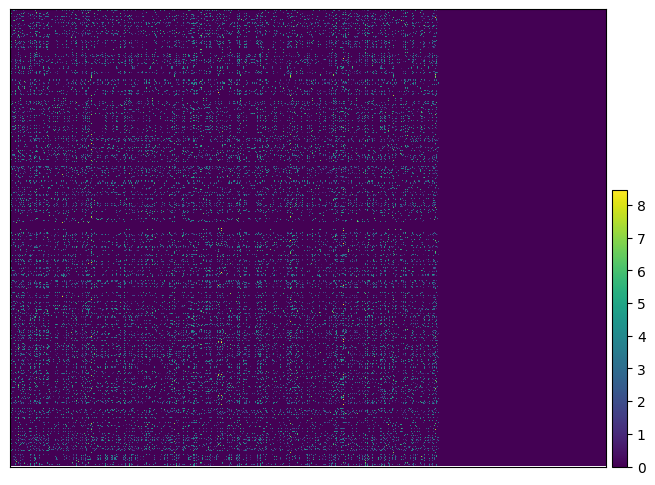

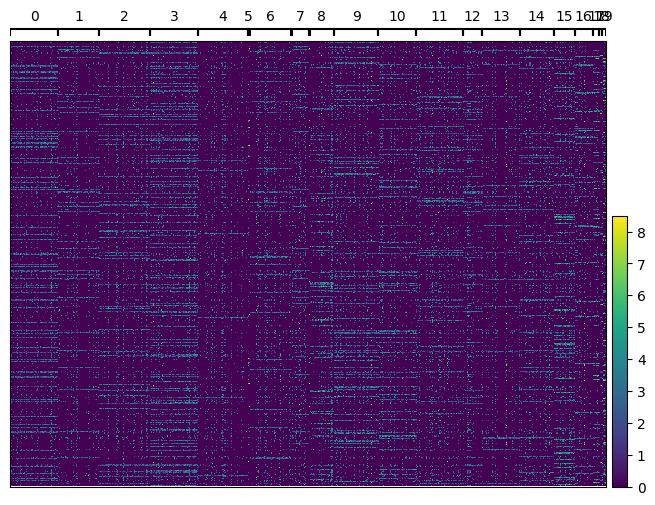

/home/icb/amirali.moinfar/miniconda3/envs/drvi/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/icb/amirali.moinfar/miniconda3/envs/drvi/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


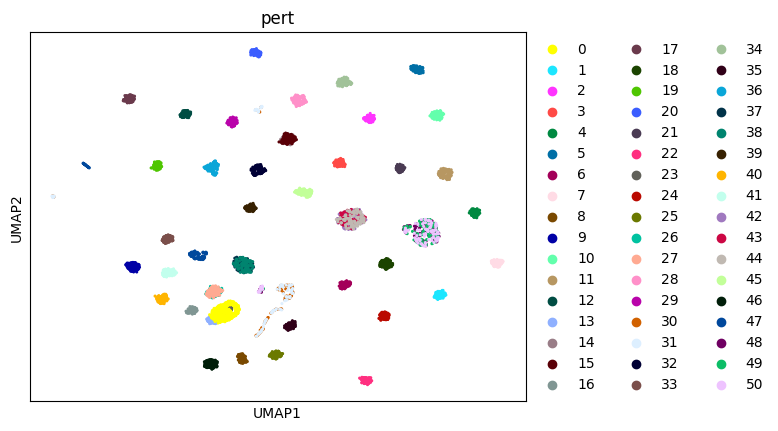

synthetic_data_overlapping_4


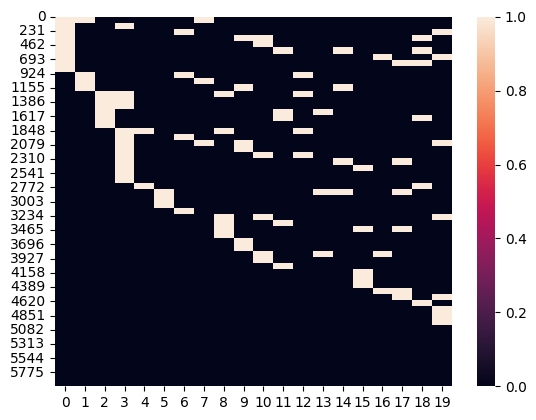

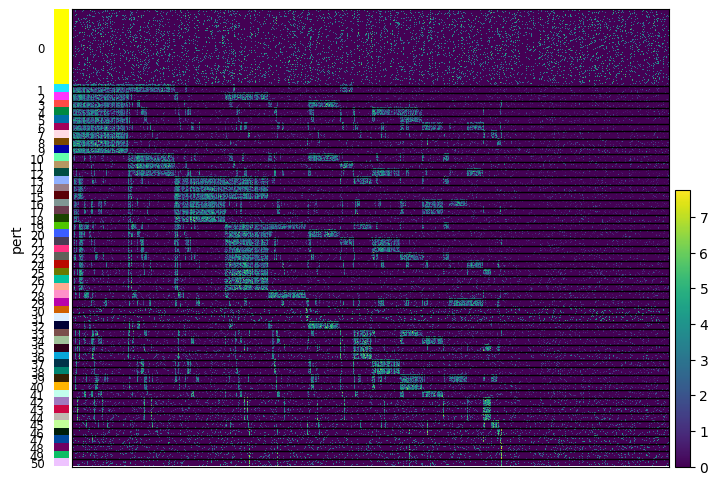

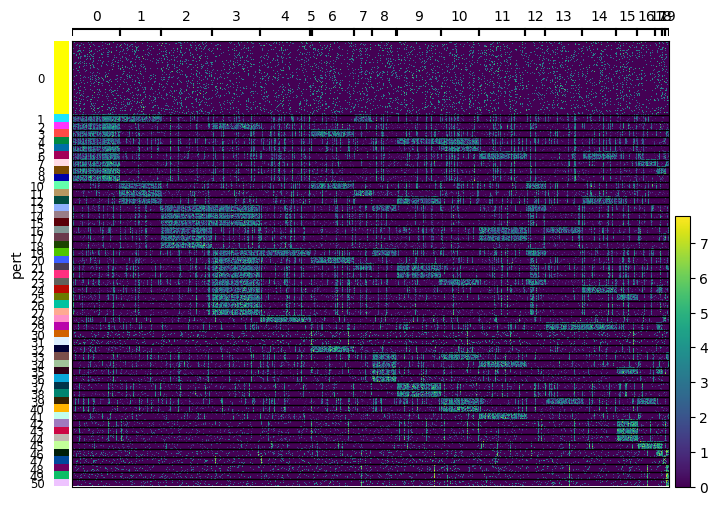

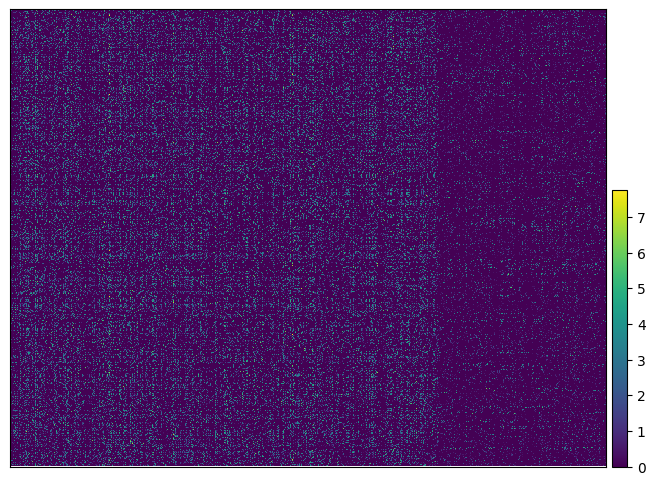

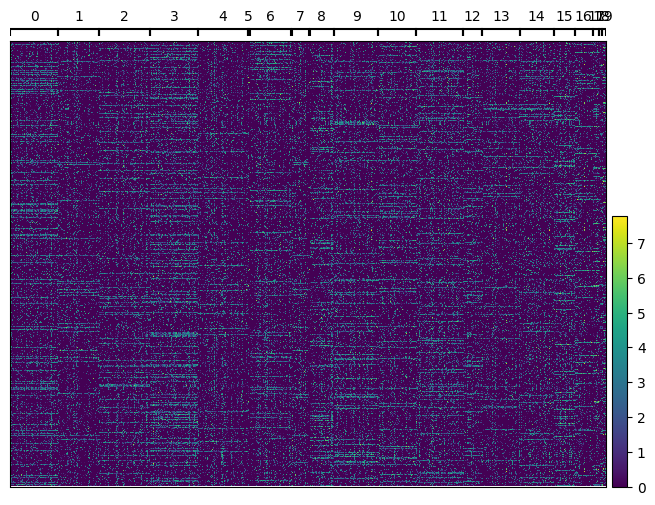

/home/icb/amirali.moinfar/miniconda3/envs/drvi/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


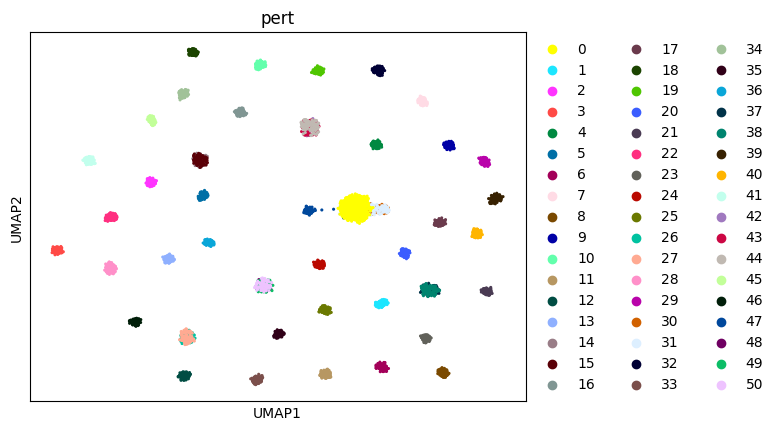

In [21]:
# Overlapping processes dataset

for data_name, adata in simulated_datasets.items():
    print(data_name)
    
    affected_genes = adata.uns["affected_genes"]
    
    sns.heatmap(adata.obsm['ground_truth_identity'])
    
    sc.pl.heatmap(adata, adata.var.index, groupby="pert", show=False)
    plt.savefig(save_path / f"{data_name}_ordered_all_genes.pdf", bbox_inches='tight')
    plt.show()
    sc.pl.heatmap(adata, affected_genes, groupby="pert", show=False)
    plt.savefig(save_path / f"{data_name}_ordered_aggected_genes.pdf", bbox_inches='tight')
    plt.show()
    
    var_shuffled = adata.var.iloc[list(np.random.permutation(np.argwhere(adata.varm['ground_truth_effect'].sum(axis=1) > 0).flatten())) + list(np.random.permutation(np.argwhere(adata.varm['ground_truth_effect'].sum(axis=1) == 0).flatten()))].index
    adata_shuffled = adata[np.random.permutation(adata.obs.index), var_shuffled].copy()
    adata_shuffled.obs['dummy'] = 'dummy'
    
    sc.pl.heatmap(adata_shuffled, adata_shuffled.var.index, groupby="dummy", show=False)
    plt.savefig(save_path / f"{data_name}_shuffled_all_genes.pdf", bbox_inches='tight')
    plt.show()
    sc.pl.heatmap(adata_shuffled, affected_genes, groupby="dummy", show=False)
    plt.savefig(save_path / f"{data_name}_shuffled_aggected_genes.pdf", bbox_inches='tight')
    plt.show()
    
    sc.tl.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata, spread=1.0, min_dist=0.5, random_state=123)
    sc.pl.umap(adata, color=['pert'], show=False)
    plt.savefig(save_path / f"{data_name}_umap.pdf", bbox_inches='tight')
    plt.show()
    
    adata_write = adata[np.random.permutation(adata.obs.index), np.random.permutation(adata.var.index)].copy()
    
    adata_write.write_h5ad(save_path / f"{data_name}.h5ad")

In [52]:
adata

AnnData object with n_obs × n_vars = 6000 × 1000
    obs: 'pert', 'perfect_order'
    var: 'perfect_order'
    uns: 'affected_genes', 'log1p', 'pert_colors', 'pca', 'neighbors', 'umap'
    obsm: 'ground_truth_identity', 'ground_truth_z', 'X_pca', 'X_umap'
    varm: 'ground_truth_effect', 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

# Collect wandb information for runs

users aiming at jusy making data should skip this part.

In [54]:
simulated_datasets.keys()

dict_keys(['synthetic_data_unique_no_noise', 'synthetic_data_unique', 'synthetic_data_overlapping_4_no_noise', 'synthetic_data_overlapping_4'])

In [61]:
import pandas as pd 
import wandb

api = wandb.Api()
api.flush()
data_name = "synthetic_data_overlapping_4"

In [62]:
# Project is specified by <entity/project-name>
runs = api.runs("moinfar_proj/simulatedDRVI_runs_drvi_4.7")

result_list = []
for run in runs: 
    result_list.append({
        'name': run.name,
        'summary': run.summary._json_dict,
        'config': {k: v for k,v in run.config.items() if not k.startswith('_')},
    })
            
runs_df = pd.json_normalize(result_list, sep='_')
runs_df = runs_df.query(f'config_params_input_adata.str.contains("{data_name}.h5ad")')
runs_df = runs_df.query('(summary_epoch == config_params_max_epochs - 1)')

runs_df['title'] = (runs_df['config_params_model'].astype(str) + '-' + runs_df['config_params_n_split_latent'].astype(str) + '-' + runs_df['config_params_split_aggregation'].astype(str)).map({
    'drvi-32-logsumexp': 'DRVI',
    'drvi-32-sum': 'DRVI-IK',
    'drvi-1-sum': 'DRVI-CVAE',
    'scvi-1-sum': 'scVI',
    'scvi-ica-1-sum': 'scVI-ICA',
    'scvi-pca-1-sum': 'scVI-PCA',
})
for k, v in zip(runs_df['title'].values, runs_df['name']):
    print(f"\t\t'{k}': logs_dir / 'models' / '{v}',")

		'scVI-PCA': logs_dir / 'models' / 'scvi-pca_20250624-171600-047246',
		'DRVI-CVAE': logs_dir / 'models' / 'drvi_20250624-171114-675676',
		'DRVI': logs_dir / 'models' / 'drvi_20250624-170610-070175',
		'scVI': logs_dir / 'models' / 'scvi_20250624-170133-310892',
		'DRVI-IK': logs_dir / 'models' / 'drvi_20250624-165437-303674',
		'scVI-ICA': logs_dir / 'models' / 'scvi-ica_20250624-164908-313875',


In [63]:
# Project is specified by <entity/project-name>
runs = api.runs(f"moinfar_proj/DRVI_runs_{data_name}_baselines_linear_1.0")

result_list = []
for run in runs: 
    result_list.append({
        'name': run.name,
        'summary': run.summary._json_dict,
        'config': {k: v for k,v in run.config.items() if not k.startswith('_')},
    })
            
runs_df = pd.json_normalize(result_list, sep='_')
runs_df = runs_df.query(f'config_params_input_adata.str.contains("{data_name}.h5ad")')

runs_df['title'] = runs_df['config_params_model'].map({
    'liger': 'LIGER',
    'ica': 'ICA',
    'pca': 'PCA',
    'scetm': 'scETM',
    'mofa': 'MOFA',
})
for k, v in zip(runs_df['title'].values, runs_df['name']):
    print(f"\t\t'{k}': logs_dir / 'models' / '{v}',")

		'MOFA': logs_dir / 'models' / 'legendary-gorge-5',
		'PCA': logs_dir / 'models' / 'hearty-capybara-4',
		'LIGER': logs_dir / 'models' / 'electric-oath-3',
		'ICA': logs_dir / 'models' / 'rose-night-2',
		'scETM': logs_dir / 'models' / 'swept-snowflake-1',
